In [40]:
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from operator import add
from langchain_groq import ChatGroq
from typing import TypedDict, Annotated
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import InMemorySaver


In [31]:
load_dotenv()

llm = ChatGroq(
    model="qwen/qwen3.8-27b",
    temperature=1,
)

# llm = ChatGoogleGenerativeAI(
#     model="gemini-3.5-flash",
#     temperature=0.1,
# )

llm.invoke("hi").content

'Hello! How can I help you today?'

In [ ]:
class SimpleState(TypedDict):
    user_input: str
    response: str

class MultiStepState(TypedDict):
    vals: Annotated[list[str], add]


In [ ]:
def ask_user(state: SimpleState) -> SimpleState:
    response = interrupt("Approve or not?")
    return {"user_input": state["user_input"], "response": response}    

def node_a(state: MultiStepState):
    answer = interrupt("question_a")
    return {"vals": [f"a:{answer}"]}


def node_b(state: MultiStepState):
    answer = interrupt("question_b")
    return {"vals": [f"b:{answer}"]}


In [43]:
store = InMemorySaver()
config = {"configurable": {"thread_id": "1"}}

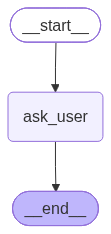

In [44]:

graph = (
    StateGraph(SimpleState)
    .add_node("ask_user", ask_user)
    .add_edge(START, "ask_user")
    .add_edge("ask_user", END)
    .compile(checkpointer=store)
)

graph

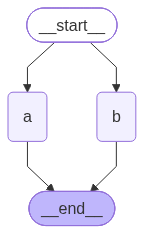

In [46]:

multi_graph = (
    StateGraph(MultiStepState)
    .add_node("a", node_a)
    .add_node("b", node_b)
    .add_edge(START, "a")
    .add_edge(START, "b")
    .add_edge("a", END)
    .add_edge("b", END)
    .compile(checkpointer=store)
)

graph

In [ ]:
# simple
result = graph.invoke({"user_input": "Hello"}, config=config)

print(result["__interrupt__"][0].value)
is_approve = input("Approve? (y/n): ")

approved = "not approved"
if(is_approve.lower() == "y" or is_approve.lower() == "yes"):
    approved = "Approved"    
result = graph.invoke(Command(resume=approved), config=config)

result

Approve or not?


{'user_input': 'Hello', 'response': 'Approved'}

In [ ]:
# parrallel Interrupts

result = multi_graph.invoke({"vals": []}, config=config)
    
print(result["__interrupt__"])


resume_map = {
    i.id: f"answer for {i.value}" for i in result["__interrupt__"]
}
resumed = multi_graph.invoke(Command(resume=resume_map), config, version="v3")


resumed

[Interrupt(value='question_a', id='d0cda3dff744547d884bc1a671abb666'), Interrupt(value='question_b', id='2286ac4e8f9513d40ef2e04828f9ba37')]


{'vals': ['a:answer for question_a', 'b:answer for question_b']}